In [65]:
from google.colab import files
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [6]:
df=pd.read_csv("Sample - Superstore.csv",encoding='latin1')

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


AttributeError: module 'matplotlib.pyplot' has no attribute 'xtricks'

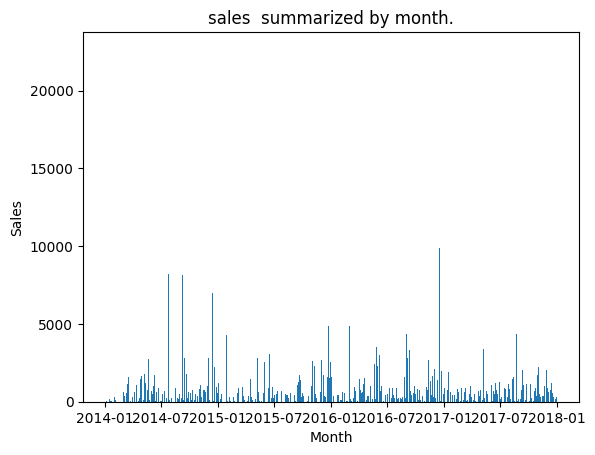

<Figure size 800x400 with 0 Axes>

In [31]:
plt.bar(df['Order Date'],df['Sales'])
plt.title('sales  summarized by month.')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.figure(figsize=(8,4))
plt.xtricks(rotation=45)
plt.show()

In [20]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')

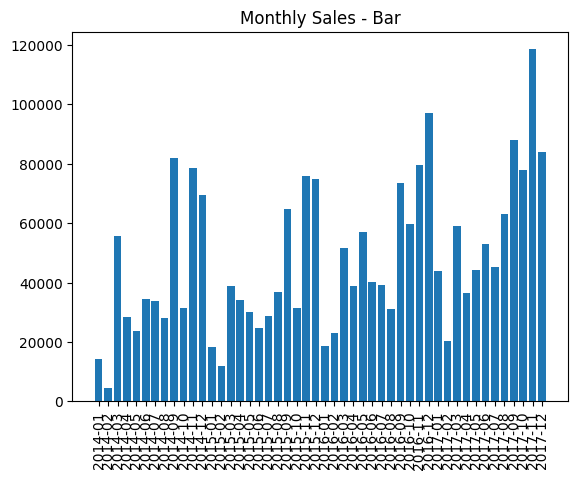

In [30]:
monthly = df.groupby('Month')['Sales'].sum().reset_index()
monthly['Month'] = monthly['Month'].astype(str)

plt.bar(monthly['Month'], monthly['Sales'])
plt.title('Monthly Sales - Bar')
plt.xticks(rotation=90)
plt.show()

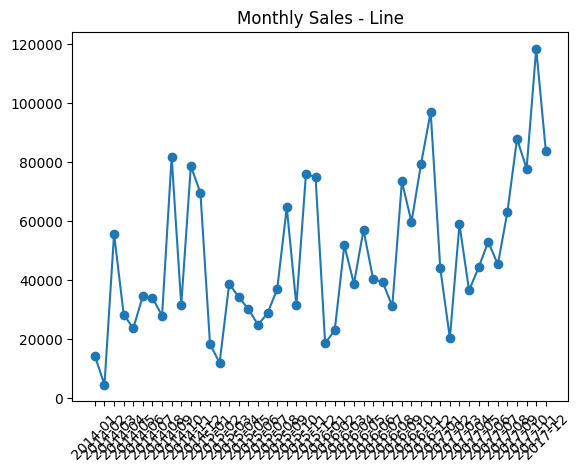

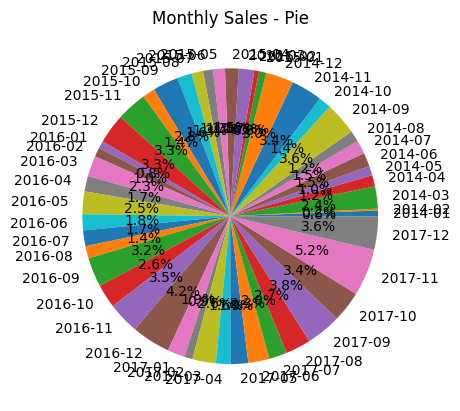

In [26]:
plt.plot(monthly['Month'], monthly['Sales'], marker='o')
plt.title('Monthly Sales - Line')
plt.xticks(rotation=45)
plt.show()

plt.pie(monthly['Sales'], labels=monthly['Month'], autopct='%1.1f%%')
plt.title('Monthly Sales - Pie')
plt.show()

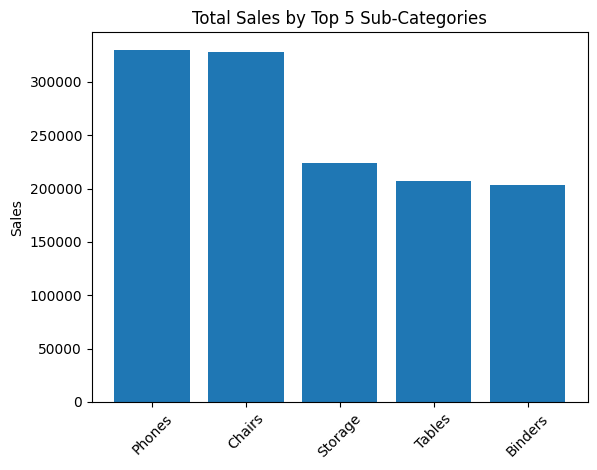

In [32]:
top5 = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(5).reset_index()

plt.bar(top5['Sub-Category'], top5['Sales'])
plt.title('Total Sales by Top 5 Sub-Categories')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

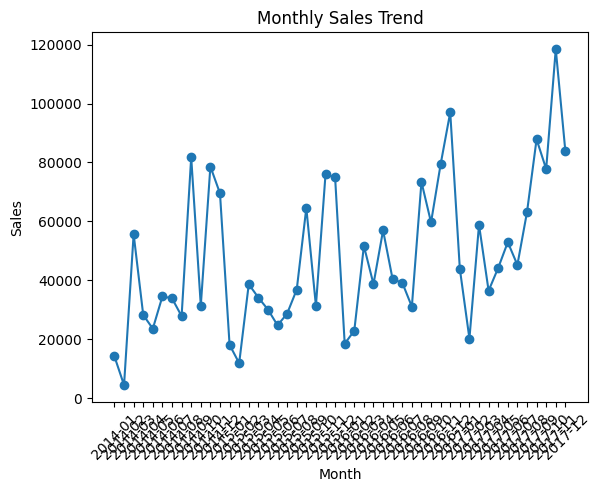

In [63]:
plt.plot(monthly['Month'], monthly['Sales'], marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

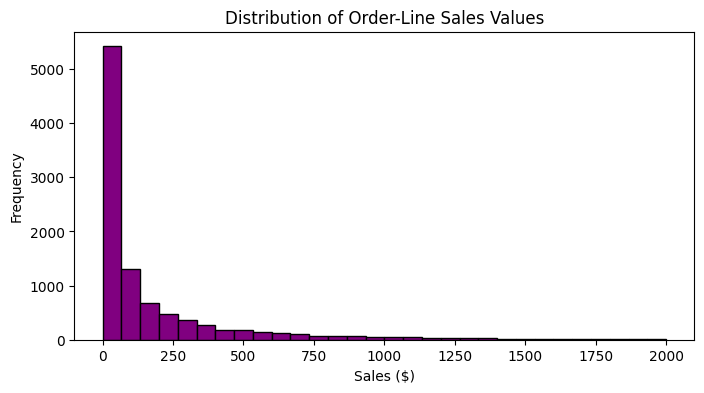

In [87]:
plt.figure(figsize=(8,4))
plt.hist(df['Sales'], edgecolor='black',bins=30,range=(0,2000),color='purple')
plt.title('Distribution of Order-Line Sales Values')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.show()

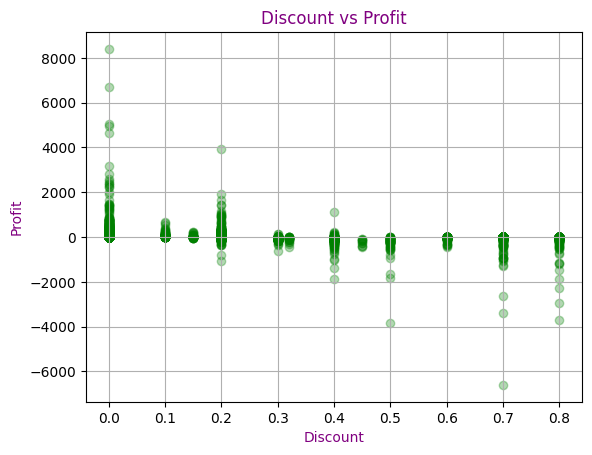

In [56]:
plt.scatter(df['Discount'], df['Profit'], alpha=0.3,color='green')
plt.grid(True)
plt.title('Discount vs Profit',color='purple')
plt.xlabel('Discount',color='purple')
plt.ylabel('Profit',color='purple')
plt.show()

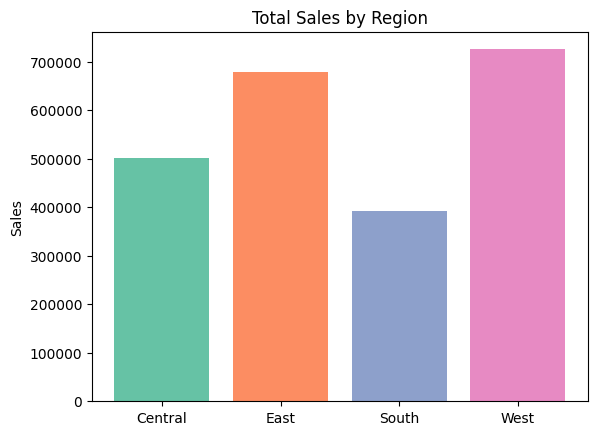

In [62]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
colors = plt.get_cmap('Set2').colors
plt.bar(region_sales['Region'], region_sales['Sales'], color=colors[:len(region_sales)])
plt.title('Total Sales by Region')
plt.ylabel('Sales')
plt.show()

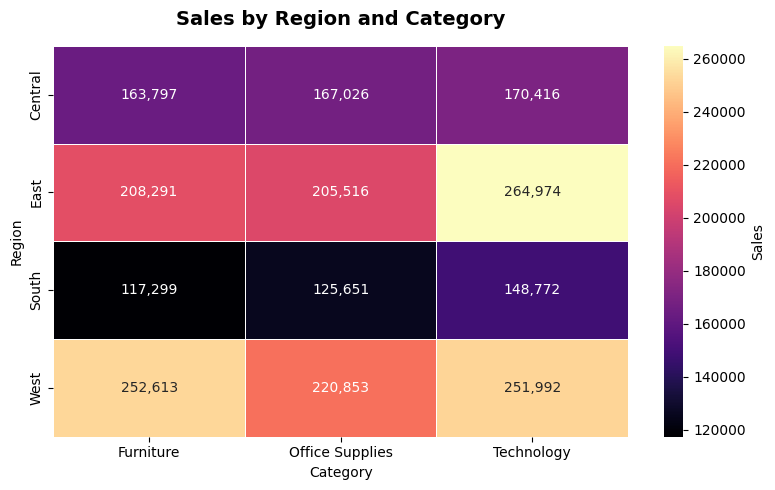

In [72]:
pivot = df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum')

plt.figure(figsize=(8, 5))
sns.heatmap( pivot,cmap='rdbu',annot=True, fmt=',.0f', linewidths=0.5,linecolor='white',cbar_kws={'label': 'Sales'})
plt.title('Sales by Region and Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Category')
plt.ylabel('Region')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

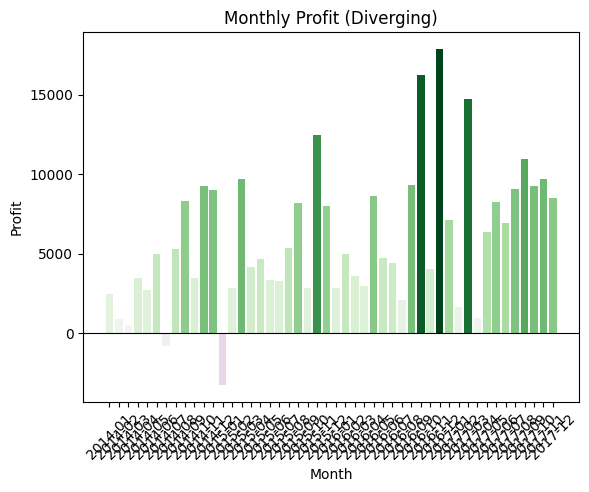

In [78]:
monthly_profit = df.groupby(df['Order Date'].dt.to_period('M'))['Profit'].sum().reset_index()
monthly_profit['Order Date'] = monthly_profit['Order Date'].astype(str)
norm = plt.Normalize(vmin=-abs(monthly_profit['Profit']).max(), vmax=abs(monthly_profit['Profit']).max())
colors = plt.get_cmap('PRGn')(norm(monthly_profit['Profit']))

plt.bar(monthly_profit['Order Date'], monthly_profit['Profit'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Monthly Profit (Diverging)')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.show()

In [79]:

def contrast_ratio(rgb1, rgb2):
    """WCAG contrast ratio between two RGB colors (0-255 each)."""
    def luminance(rgb):
        r, g, b = [c / 255 for c in rgb]
        r, g, b = [c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4 for c in (r, g, b)]
        return 0.2126 * r + 0.7152 * g + 0.0722 * b

    l1, l2 = luminance(rgb1), luminance(rgb2)
    lighter, darker = max(l1, l2), min(l1, l2)
    return (lighter + 0.05) / (darker + 0.05)

# Colors from Task 3, tested against white background
colors = {
    'Set2 green':   (102, 194, 165),
    'Set2 orange':  (252, 141, 98),
    'Blues light':  (222, 235, 247),
    'Blues dark':   (8, 48, 107),
    'RdBu red':     (178, 24, 43),
    'RdBu blue':    (33, 102, 172),
}

white = (255, 255, 255)

for name, rgb in colors.items():
    ratio = contrast_ratio(rgb, white)
    status = "PASS" if ratio >= 4.5 else "FAIL"
    print(f"{name}: {ratio:.2f}:1 - {status}")

Set2 green: 2.14:1 - FAIL
Set2 orange: 2.30:1 - FAIL
Blues light: 1.21:1 - FAIL
Blues dark: 12.76:1 - PASS
RdBu red: 6.87:1 - PASS
RdBu blue: 5.90:1 - PASS


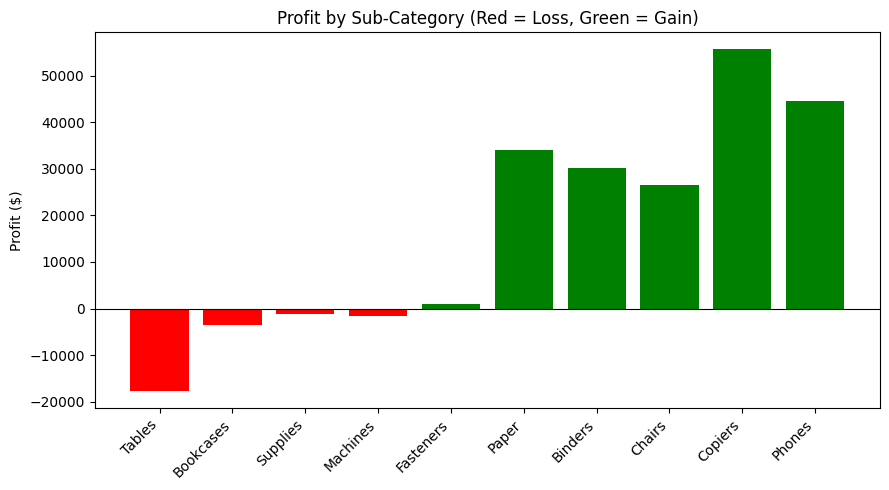

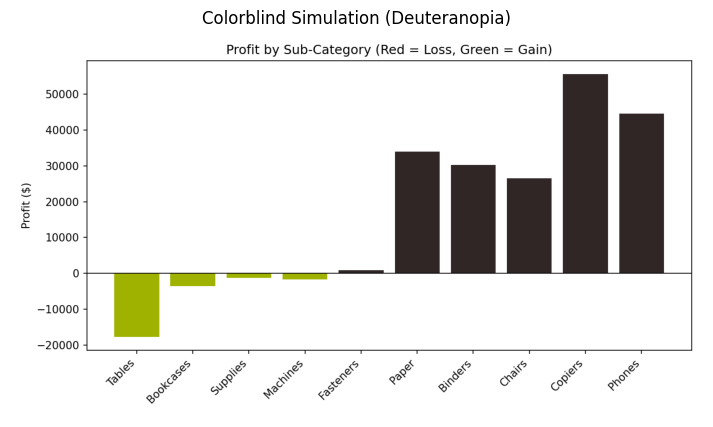

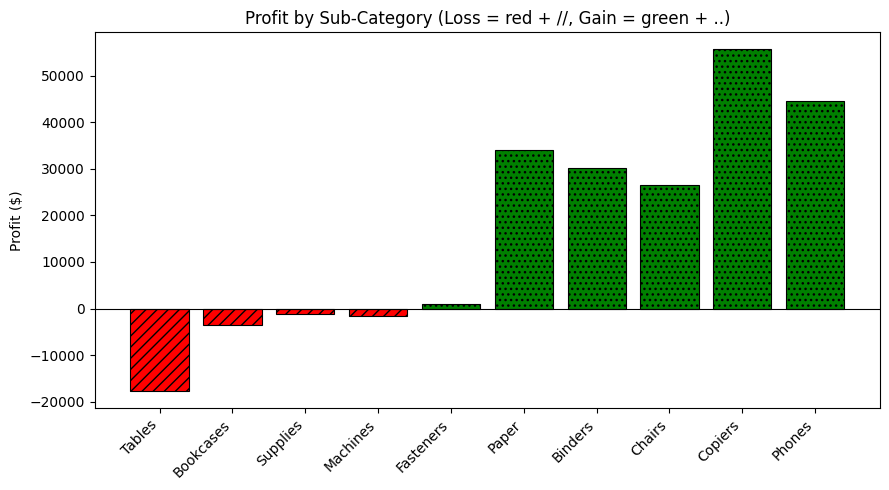

In [86]:
import matplotlib.pyplot as plt
import numpy as np

# Profit by sub-category
sub_categories = ['Tables', 'Bookcases', 'Supplies', 'Machines', 'Fasteners',
                   'Paper', 'Binders', 'Chairs', 'Copiers', 'Phones']
profit = [-17725, -3473, -1189, -1600, 950, 34000, 30221, 26590, 55618, 44516]

# --- Original chart: red/green only ---
colors = ['red' if p < 0 else 'green' for p in profit]

plt.figure(figsize=(9, 5))
plt.bar(sub_categories, profit, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Profit by Sub-Category (Red = Loss, Green = Gain)')
plt.ylabel('Profit ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('original_chart.png', dpi=150)
plt.show()

def simulate_deuteranopia(rgb):
    matrix = np.array([
        [0.625, 0.375, 0.0],
        [0.7,   0.3,   0.0],
        [0.0,   0.3,   0.7]
    ])
    return np.clip(matrix @ np.array(rgb), 0, 1)

img = plt.imread('original_chart.png')
sim = np.apply_along_axis(simulate_deuteranopia, 2, img[:, :, :3])

plt.figure(figsize=(9, 5))
plt.imshow(sim)
plt.axis('off')
plt.title('Colorblind Simulation (Deuteranopia)')
plt.show()

# --- Fixed chart: color + hatching ---
plt.figure(figsize=(9, 5))
for cat, p in zip(sub_categories, profit):
    color = 'red' if p < 0 else 'green'
    hatch = '///' if p < 0 else '...'
    plt.bar(cat, p, color=color, hatch=hatch, edgecolor='black', linewidth=0.8)

plt.axhline(0, color='black', linewidth=0.8)
plt.title('Profit by Sub-Category (Loss = red + //, Gain = green + ..)')
plt.ylabel('Profit ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

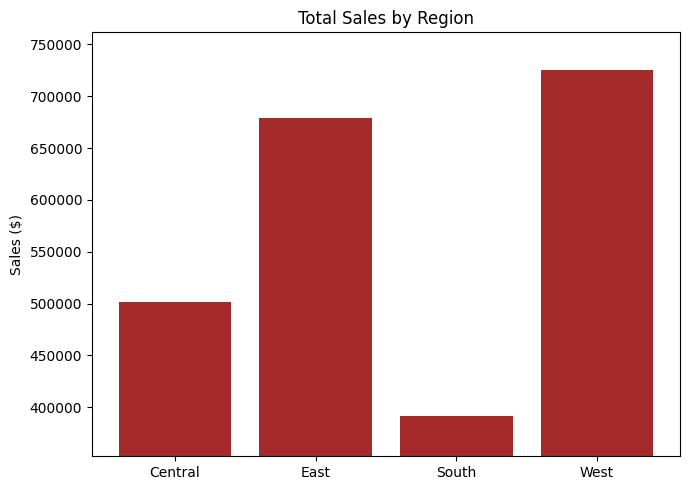

In [81]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(region_sales['Region'], region_sales['Sales'], color='brown')
ax.set_ylim(region_sales['Sales'].min() * 0.9, region_sales['Sales'].max() * 1.05)  # truncated - doesn't start at 0
ax.set_title('Total Sales by Region')
ax.set_ylabel('Sales ($)')
plt.tight_layout()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (48,) and (12,)

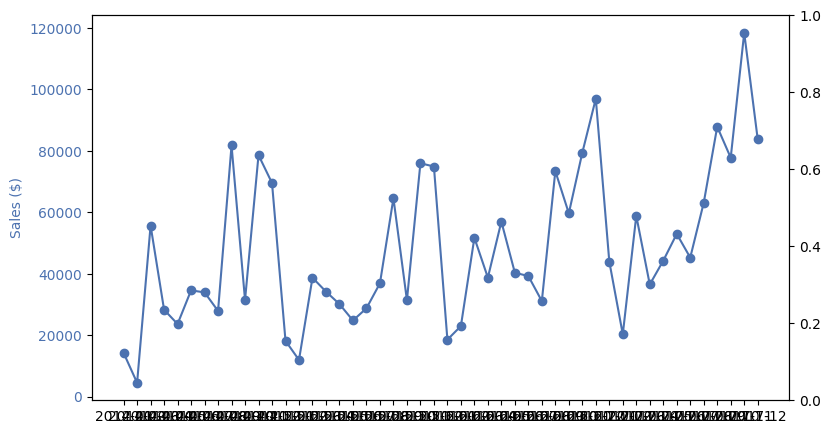

In [83]:
# --- 2. Dual-axis fake correlation: monthly sales vs. an unrelated measure ---
unrelated_measure = [12, 14, 11, 15, 10, 16, 9, 17, 8, 18, 7, 19]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(monthly['Month'], monthly['Sales'], color='#4C72B0', marker='o', label='Monthly Sales')
ax1.set_ylabel('Sales ($)', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')

ax2 = ax1.twinx()
ax2.plot(monthly['Month'], unrelated_measure, color='#C44E52', marker='s', label='Unrelated Measure')
ax2.set_ylabel('Unrelated Measure (arbitrary units)', color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')

plt.title('Monthly Sales vs. Unrelated Measure (Dual-Axis)')
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()


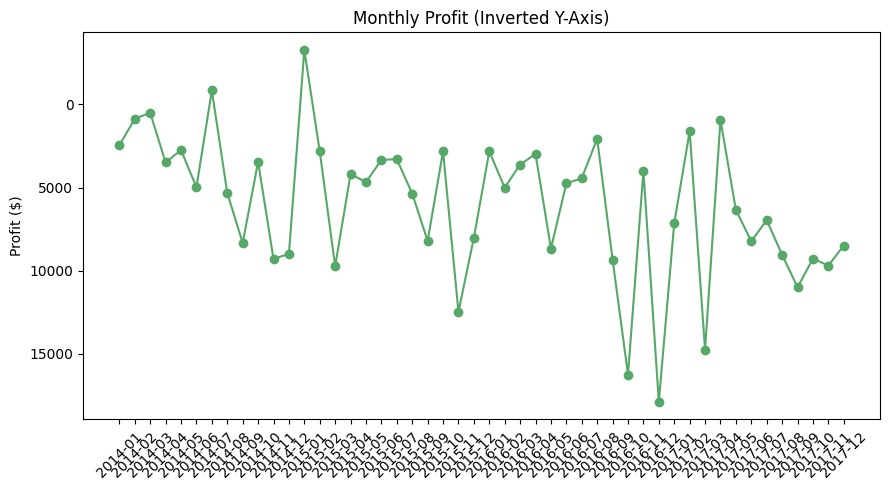

In [82]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(monthly_profit['Order Date'], monthly_profit['Profit'], color='#55A868', marker='o')
ax.invert_yaxis()  # inverted - up looks like down
ax.set_title('Monthly Profit (Inverted Y-Axis)')
ax.set_ylabel('Profit ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

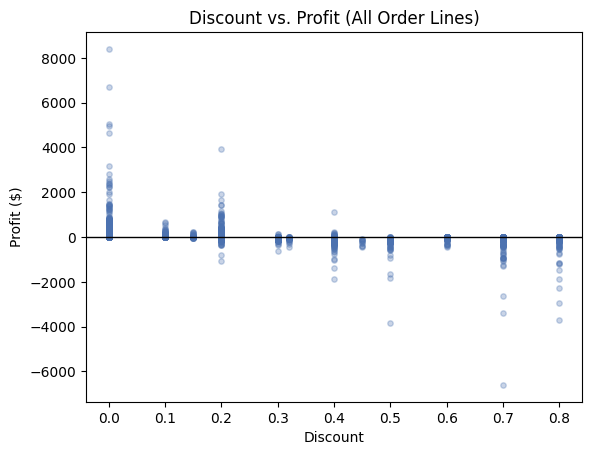

In [84]:
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, s=15, color='#4C72B0')
plt.axhline(0, color='black', linewidth=1)
plt.title('Discount vs. Profit (All Order Lines)')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.show()


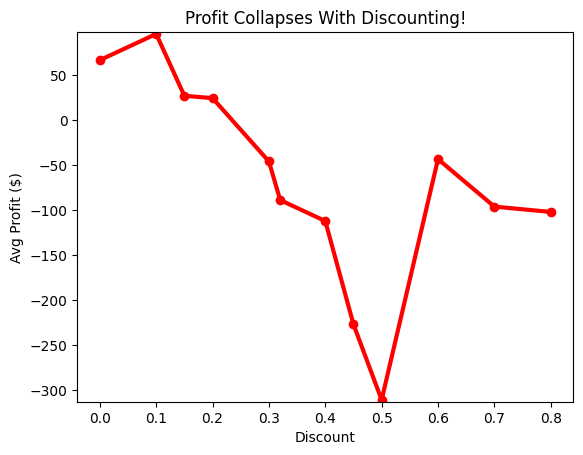

In [85]:
avg_by_discount = df.groupby('Discount')['Profit'].mean().reset_index()

plt.plot(avg_by_discount['Discount'], avg_by_discount['Profit'], color='red', marker='o', linewidth=3)
plt.ylim(avg_by_discount['Profit'].min() - 2, avg_by_discount['Profit'].max() + 2)
plt.title('Profit Collapses With Discounting!')
plt.xlabel('Discount')
plt.ylabel('Avg Profit ($)')
plt.show()